Dataset: Fake_Bills.csv
Information: https://www.kaggle.com/datasets/alexandrepetit881234/fake-bills/dataLinks to an external site.

Steps:
I) EDA
II) Preprocessing Data
III) Linear Regression
IV) Logistic Regression
V) Conclusion

Import Data and Required Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix
import statsmodels.api as sm

Set larger font sizes and the style

In [2]:
font_size = 14
mpl.rcParams.update({'font.size': font_size})
mpl.rcParams['xtick.labelsize'] = font_size-5
mpl.rcParams['ytick.labelsize'] = font_size-5
plt.style.use('bmh')

Import Data

In [3]:
df = pd.read_csv("fake_bills.csv", sep=";")

Display the first few rows

In [4]:
df.head()

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


I) EDA

Check basic information about the dataset

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1463 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: bool(1), float64(6)
memory usage: 71.9 KB


Display basic statistics

In [6]:
df.describe()

,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500.000000,1500.000000,1500.000000,1463.000000,1500.000000,1500.00000
mean,171.958440,104.029533,103.920307,4.485967,3.151473,112.67850
std,0.305195,0.299462,0.325627,0.663813,0.231813,0.87273
min,171.040000,103.140000,102.820000,2.980000,2.270000,109.49000
25%,171.750000,103.820000,103.710000,4.015000,2.990000,112.03000
50%,171.960000,104.040000,103.920000,4.310000,3.140000,112.96000
75%,172.170000,104.230000,104.150000,4.870000,3.310000,113.34000
max,173.010000,104.880000,104.950000,6.900000,3.910000,114.44000


Check for missing values

Shape

In [7]:
df.shape

(1500, 7)

In [8]:
df.isnull().sum()

is_genuine       0
diagonal         0
height_left      0
height_right     0
margin_low      37
margin_up        0
length           0
dtype: int64

Check for duplicate rows

In [9]:
df.duplicated().sum()

np.int64(0)

Visualizing the distribution of numerical features

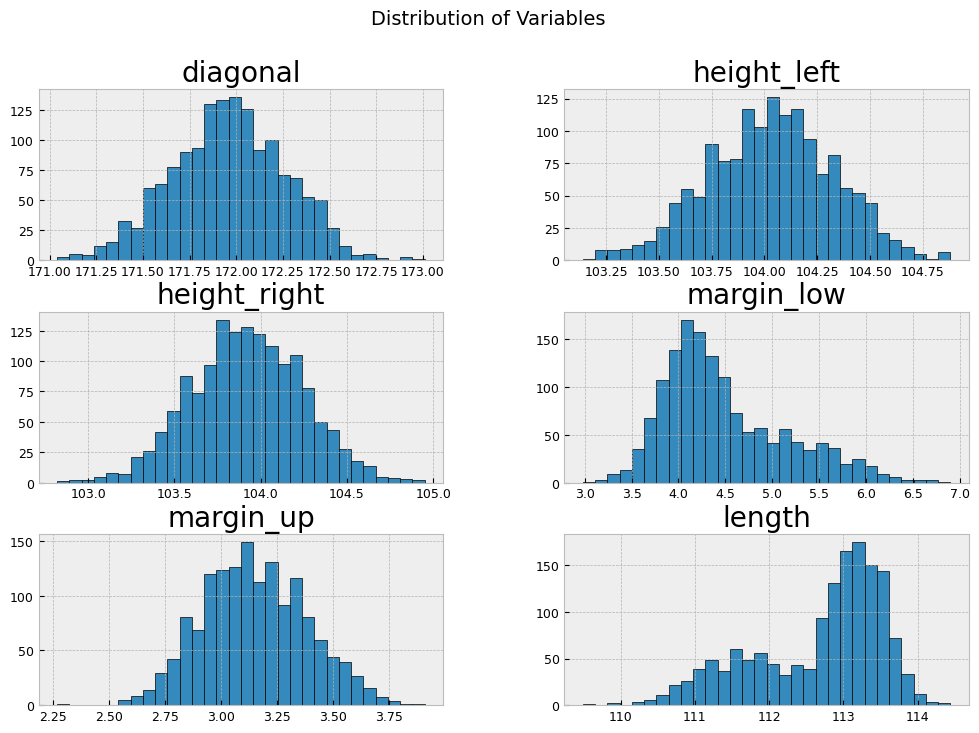

In [10]:
df.hist(figsize=(12, 8), bins=30, edgecolor='black')
plt.suptitle("Distribution of Variables", fontsize=14)
plt.show()

Ditribution Of Genuine vs Fake

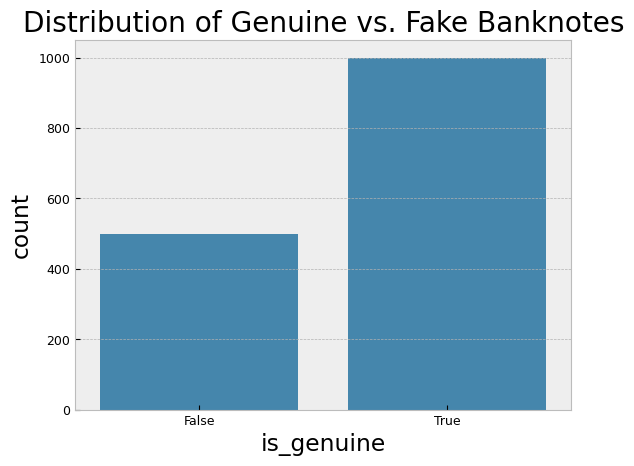

In [11]:
sns.countplot(x="is_genuine", data=df)
plt.title("Distribution of Genuine vs. Fake Banknotes")
plt.show()

Compute and visualize the correlation matrix

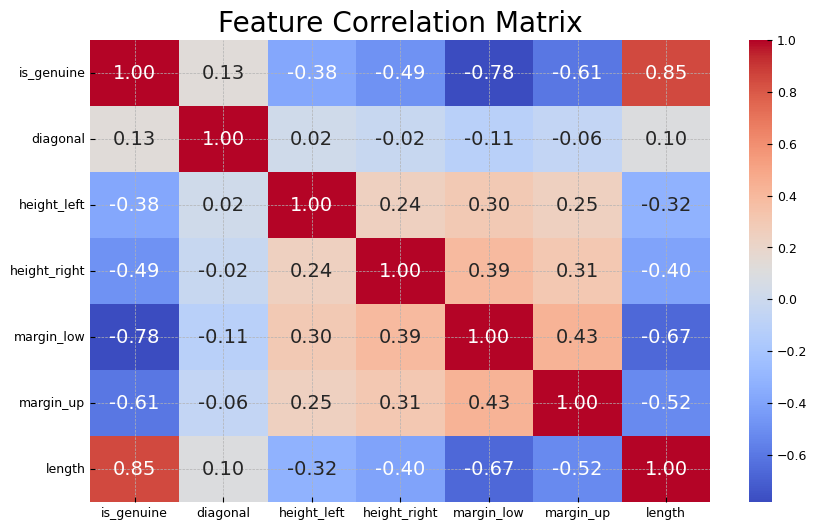

In [12]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

Check the target variable distribution

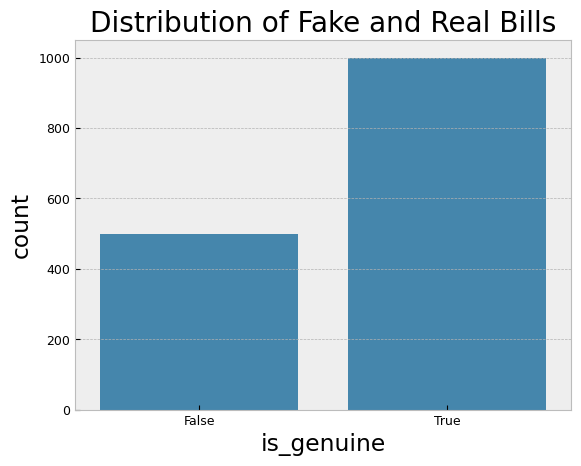

In [13]:
sns.countplot(x=df['is_genuine'])
plt.title("Distribution of Fake and Real Bills")
plt.show()

II) Preprocessing

Check for missing values

In [14]:
print(df.isnull().sum())

is_genuine       0
diagonal         0
height_left      0
height_right     0
margin_low      37
margin_up        0
length           0
dtype: int64


Replace null with column mean

In [15]:
df.fillna(df.mean(), inplace=True)

In [16]:
print(df.isnull().sum())

is_genuine      0
diagonal        0
height_left     0
height_right    0
margin_low      0
margin_up       0
length          0
dtype: int64


Remove duplicate rows if any

In [17]:
df.drop_duplicates(inplace=True)

Convert Categorical Data 

In [18]:
df.dtypes

is_genuine         bool
diagonal        float64
height_left     float64
height_right    float64
margin_low      float64
margin_up       float64
length          float64
dtype: object

In [19]:
df = pd.get_dummies(df, drop_first=True)

In [20]:
print(df.columns)

Index(['is_genuine', 'diagonal', 'height_left', 'height_right', 'margin_low',
       'margin_up', 'length'],
      dtype='object')


III) Linear Regression

In [21]:
X = df.drop(columns=['length'])  # Features
y = df['is_genuine']  # Target

Splitting Data into Training and Testing Sets

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Standardization (Scaling)

In [23]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # Fit and transform on training data
X_test = scaler.transform(X_test)  # Only transform test data

Train the Linear Regression Model

In [24]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

LinearRegression()

Make Predictions

In [25]:
y_pred = lin_reg.predict(X_test)

Evaluate the Model

In [26]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared Score: {r2}")

Mean Squared Error: 1.5641632636335374e-31
R-squared Score: 1.0


In [27]:
X = df[['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length']]
X = sm.add_constant(X)  # Add a constant term to the features
Y = df['is_genuine'].astype(int)

# Fit the multivariate regression model
model = sm.OLS(Y, X).fit()

# Print the summary of the regression results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             is_genuine   R-squared:                       0.841
Model:                            OLS   Adj. R-squared:                  0.841
Method:                 Least Squares   F-statistic:                     1318.
Date:                Wed, 30 Apr 2025   Prob (F-statistic):               0.00
Time:                        00:22:09   Log-Likelihood:                 379.85
No. Observations:                1500   AIC:                            -745.7
Df Residuals:                    1493   BIC:                            -708.5
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -12.1367      3.747     -3.239   

Visualizing the Predictions

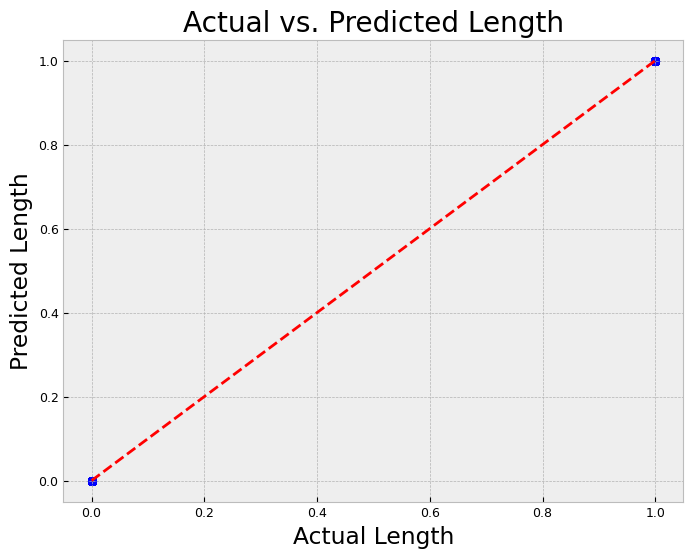

In [28]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5, color="blue")
plt.xlabel("Actual Length")
plt.ylabel("Predicted Length")
plt.title("Actual vs. Predicted Length")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='dashed')  # Diagonal reference line
plt.show()

IV) Logistic Regression 

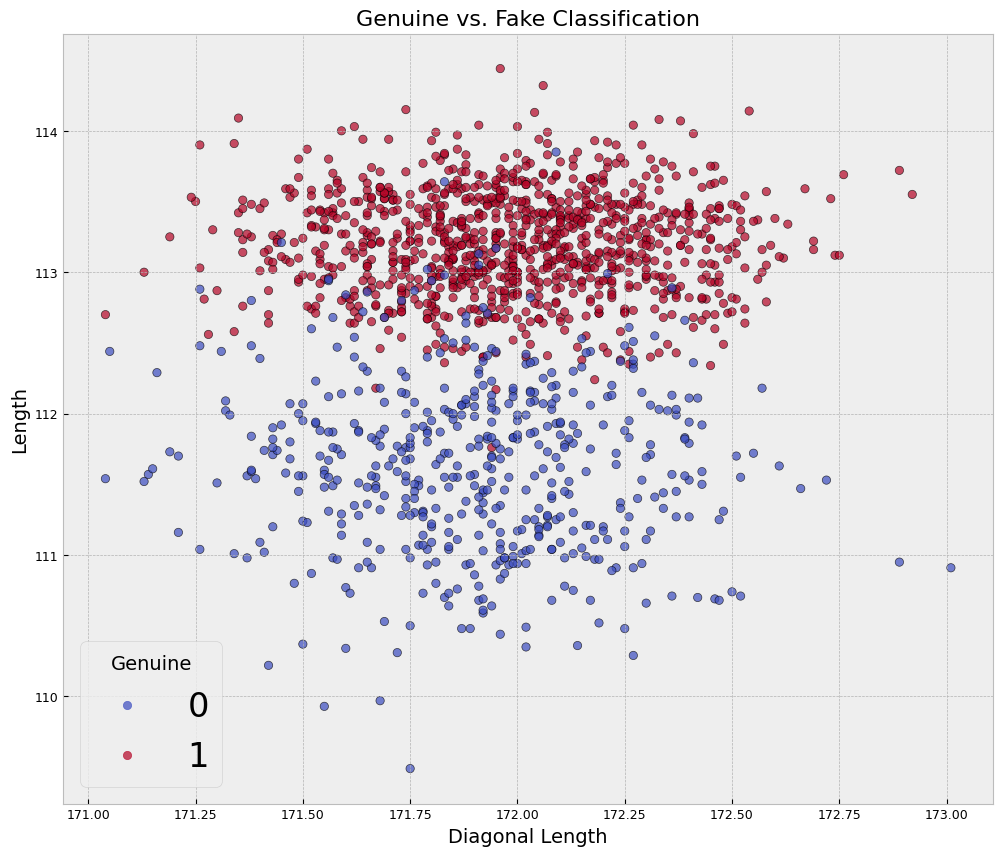

In [29]:
# Convert True/False to 1/0 for logistic regression
df['is_genuine'] = df['is_genuine'].astype(int)

# Select two features for visualization
X_feature1 = df['diagonal']
X_feature2 = df['length']
y = df['is_genuine']

# Create scatter plot
fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(111)

# Scatter plot with color based on class
scatter = ax.scatter(X_feature1, X_feature2, c=y, cmap='coolwarm', edgecolors='k', alpha=0.7)

# Legend and labels
ax.legend(*scatter.legend_elements(), title="Genuine", fontsize='xx-large')
ax.set_xlabel('Diagonal Length', fontsize=14)
ax.set_ylabel('Length', fontsize=14)
ax.set_title('Genuine vs. Fake Classification', fontsize=16)

plt.show()

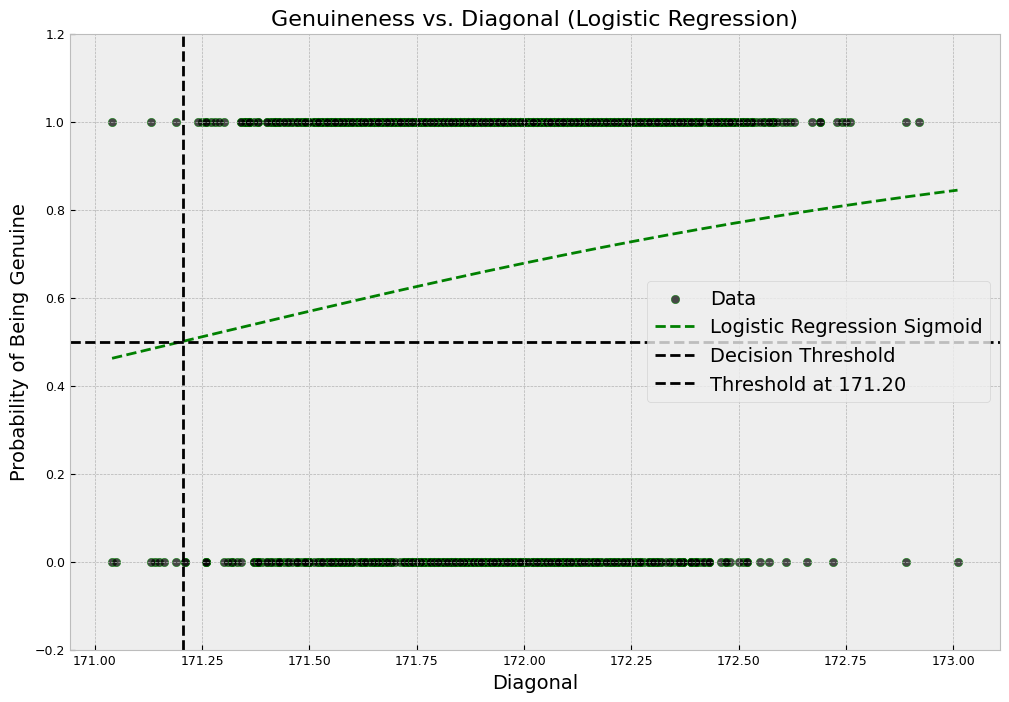

In [30]:
# Select a feature (change 'diagonal' to other features if needed)
X_feature = df[['diagonal']]  # Must be 2D
y = df['is_genuine']

# Scale feature for better sigmoid curve
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_feature)

# Train Logistic Regression
model = LogisticRegression()
model.fit(X_scaled, y)

# Generate a range of values for plotting the sigmoid function
x_ = np.linspace(X_scaled.min(), X_scaled.max(), 300).reshape(-1, 1)
sigmoid = model.predict_proba(x_)[:, 1]  # Probability of being genuine

# Convert scaled x values back to original feature range
x_original = scaler.inverse_transform(x_)

# Plot data points
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111)
ax.scatter(df['diagonal'], y, color='k', edgecolor='g', alpha=0.7, label='Data')

# Plot sigmoid curve
ax.plot(x_original, sigmoid, 'g--', label='Logistic Regression Sigmoid')

# Probability threshold line (0.5 decision boundary)
ax.axhline(0.5, color='k', linestyle='--', label='Decision Threshold')

# Find decision boundary value in original scale
threshold_index = np.abs(sigmoid - 0.5).argmin()
threshold_value = x_original[threshold_index][0]
ax.axvline(threshold_value, color='k', linestyle='--', label=f'Threshold at {threshold_value:.2f}')

# Labels and titles
ax.set_xlabel('Diagonal', fontsize=14)
ax.set_ylabel('Probability of Being Genuine', fontsize=14)
ax.set_title('Genuineness vs. Diagonal (Logistic Regression)', fontsize=16)
ax.set_ylim([-0.2, 1.2])
ax.legend()

plt.show()

Define Features (X) and Target Variable (y)

In [31]:
X = df.drop(columns=['is_genuine'])  # Features (all columns except "is_genuine")
y = df['is_genuine']  # Target variable (1 = Genuine, 0 = Fake)

Split the Data

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Normalize the Features (Standardization)

In [33]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # Fit and transform training data
X_test = scaler.transform(X_test)  # Transform test data (without fitting again)

Train the Logistic Regression Model

In [34]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

LogisticRegression()

Make Predictions

In [35]:
y_pred = log_reg.predict(X_test)

Evaluate the Model

In [36]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.99


Classification Report (Precision, Recall, F1-score)

In [37]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       100
           1       0.99      0.99      0.99       200

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



Confusion Matrix (Visualizing Predictions)

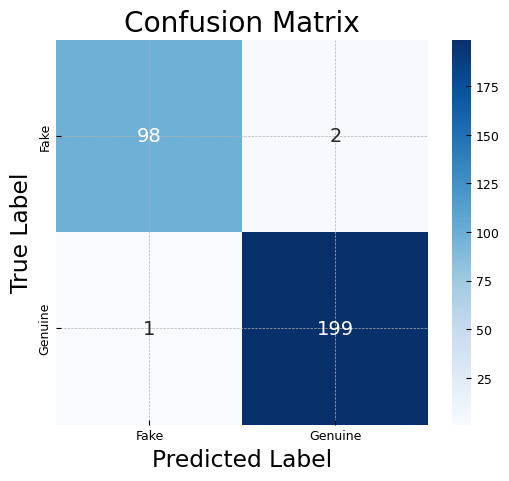

In [38]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Fake", "Genuine"], yticklabels=["Fake", "Genuine"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

V) Conclusion

EDA:
The dataset was examined for missing values, duplicate records, and general statistical properties.
Visualization techniques helped to identify differences between genuine and counterfeit banknotes.

Data preprocessing:
Missing values ​​were handled using mean imputation.
Data was standardized to ensure consistency across features.

Linear regression model:
A regression model was trained and tested, although its applicability for classification may be limited.
Model evaluation metrics (e.g., RMSE, R²) were calculated, showing that linear regression is not the best choice for a classification problem.

Logistic regression model:
A more suitable approach for binary classification (fake vs. authentic).
Model performance was assessed using accuracy, precision, recall, F1 score, and a confusion matrix.

Final conclusions:
Logistic regression outperformed linear regression due to its classification nature.
Data preprocessing and standardization played a crucial role in the effectiveness of the model.